## Generic time-series forecasting model

Now I build the main forecasting model required by the project.  
The goal is to train **one shared model for all stocks** and then evaluate its performance **for each ticker separately**.

I predict the **next-day return** and then convert it into the **next-day closing price**.  
This is useful because returns are more comparable across stocks than raw prices.

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## Prepare data for forecasting

First, I prepare the modeling dataset.  
I create the target as the **next-day return** and also store the **next-day close** so I can evaluate price predictions later.

In [20]:
data_path = Path("../01_data/raw/df_eda.csv")
df_model = pd.read_csv(data_path)

print("Shape:", df_model.shape)
df_model.head()

Shape: (19836, 17)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


In [21]:
ts_df = df_model.copy()

ts_df["Date"] = pd.to_datetime(ts_df["Date"])
ts_df = ts_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Target: next-day return
ts_df["Target_Return_1d"] = (
    ts_df.groupby("Ticker")["Close"].pct_change(1).shift(-1)
)

# Actual next-day closing price
ts_df["Target_Next_Close"] = ts_df.groupby("Ticker")["Close"].shift(-1)

ts_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month,Target_Next_Close
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January,7.656429
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January,7.534643
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January,7.520714
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January,7.570714
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January,7.503929


### Select features

I use historical price, volume, return, and volatility features that were created earlier.  
I also include the ticker so the shared model can still learn stock-specific patterns.

In [22]:
feature_cols = [
    "Ticker",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volume_Change_1d"
]

target_col = "Target_Return_1d"

model_data = ts_df.dropna(subset=feature_cols + [target_col, "Target_Next_Close"]).copy()

print(model_data.shape)
model_data.head()

(19806, 18)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month,Target_Next_Close
5,2010-01-11,7.600000,7.607143,7.444643,7.503929,6.295528,462229600,AAPL,-0.008821,-0.004076,-0.018223,0.008877,NaN,0.032660,-0.011375,Monday,January,7.418571
6,2010-01-12,7.471071,7.491786,7.372143,7.418571,6.223914,594459600,AAPL,-0.011375,-0.013582,-0.031067,0.008830,NaN,0.286070,0.014106,Tuesday,January,7.523214
7,2010-01-13,7.423929,7.533214,7.289286,7.523214,6.311707,605892000,AAPL,0.014106,-0.006274,-0.001517,0.010647,NaN,0.019232,-0.005792,Wednesday,January,7.479643
8,2010-01-14,7.503929,7.516429,7.465000,7.479643,6.275150,432894000,AAPL,-0.005792,-0.003237,-0.005461,0.010937,NaN,-0.285526,-0.016712,Thursday,January,7.354643
9,2010-01-15,7.533214,7.557143,7.352500,7.354643,6.170283,594067600,AAPL,-0.016712,-0.008617,-0.028540,0.011784,NaN,0.372317,0.044238,Friday,January,7.680000


### Create a time-based split

Because this is time-series data, I do not use a random split.  
Older data is used for training, newer data for validation, and the most recent data for testing.

In [23]:
unique_dates = np.sort(model_data["Date"].unique())

train_end = unique_dates[int(len(unique_dates) * 0.70)]
valid_end = unique_dates[int(len(unique_dates) * 0.85)]

train_df = model_data[model_data["Date"] <= train_end].copy()
valid_df = model_data[(model_data["Date"] > train_end) & (model_data["Date"] <= valid_end)].copy()
test_df = model_data[model_data["Date"] > valid_end].copy()

print("Train period:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Validation period:", valid_df["Date"].min().date(), "to", valid_df["Date"].max().date())
print("Test period:", test_df["Date"].min().date(), "to", test_df["Date"].max().date())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(valid_df))
print("Test:", len(test_df))

Train period: 2010-01-11 to 2021-05-17
Validation period: 2021-05-18 to 2023-10-20
Test period: 2023-10-23 to 2026-04-01

Rows:
Train: 13686
Validation: 3060
Test: 3060


### Split features and target

Here I separate the input variables from the prediction target.  
The model will learn from the training set only and will be checked on unseen validation and test periods.

In [24]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

### Build the generic forecasting model

I use a Random Forest regressor as the first stronger model after the baseline.  
It can capture non-linear relationships and interactions better than a simple linear model.

In [25]:
numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volume_Change_1d"
]

categorical_features = ["Ticker"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

forecast_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

### Train the model

Now I fit one shared model on all training observations from all stocks.  
This matches the project requirement of using the same model for every ticker.

In [26]:
forecast_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Make predictions

The model predicts next-day return first.  
Then I convert predicted return into predicted next-day closing price for easier interpretation.

In [27]:
def build_prediction_frame(df, X, model):
    results = df[["Date", "Ticker", "Close", "Target_Return_1d", "Target_Next_Close"]].copy()
    results["Predicted_Return_1d"] = model.predict(X)
    results["Predicted_Next_Close"] = results["Close"] * (1 + results["Predicted_Return_1d"])
    results["Directional_Hit"] = (
        np.sign(results["Target_Return_1d"]) == np.sign(results["Predicted_Return_1d"])
    ).astype(int)
    return results

valid_results = build_prediction_frame(valid_df, X_valid, forecast_model)
test_results = build_prediction_frame(test_df, X_test, forecast_model)

test_results.head()

,Date,Ticker,Close,Target_Return_1d,Target_Next_Close,Predicted_Return_1d,Predicted_Next_Close,Directional_Hit
3474,2023-10-23,AAPL,173.000000,0.002543,173.440002,0.000986,173.170612,1
3475,2023-10-24,AAPL,173.440002,-0.013492,171.100006,0.000768,173.573191,0
3476,2023-10-25,AAPL,171.100006,-0.024606,166.889999,0.000757,171.229501,0
3477,2023-10-26,AAPL,166.889999,0.007969,168.220001,0.001728,167.178394,1
3478,2023-10-27,AAPL,168.220001,0.012305,170.289993,0.000905,168.372171,1


### Evaluate model performance

I evaluate the model using both **return-based** and **price-based** metrics.  
I also calculate **directional accuracy**, which shows how often the model correctly predicts the direction of the next-day move.

In [28]:
def regression_summary(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def evaluate_split(results, split_name):
    overall_return = regression_summary(
        results["Target_Return_1d"],
        results["Predicted_Return_1d"]
    )

    overall_price = regression_summary(
        results["Target_Next_Close"],
        results["Predicted_Next_Close"]
    )

    overall = pd.DataFrame([{
        "Split": split_name,
        "Return_MAE": overall_return["MAE"],
        "Return_RMSE": overall_return["RMSE"],
        "Return_R2": overall_return["R2"],
        "Price_MAE": overall_price["MAE"],
        "Price_RMSE": overall_price["RMSE"],
        "Price_R2": overall_price["R2"],
        "Directional_Accuracy": results["Directional_Hit"].mean()
    }])

    per_stock = []
    for ticker, grp in results.groupby("Ticker"):
        stock_return = regression_summary(grp["Target_Return_1d"], grp["Predicted_Return_1d"])
        stock_price = regression_summary(grp["Target_Next_Close"], grp["Predicted_Next_Close"])

        per_stock.append({
            "Ticker": ticker,
            "Split": split_name,
            "Rows": len(grp),
            "Return_MAE": stock_return["MAE"],
            "Return_RMSE": stock_return["RMSE"],
            "Return_R2": stock_return["R2"],
            "Price_MAE": stock_price["MAE"],
            "Price_RMSE": stock_price["RMSE"],
            "Price_R2": stock_price["R2"],
            "Directional_Accuracy": grp["Directional_Hit"].mean()
        })

    per_stock = pd.DataFrame(per_stock).sort_values("Price_RMSE")
    return overall, per_stock

valid_overall, valid_by_stock = evaluate_split(valid_results, "Validation")
test_overall, test_by_stock = evaluate_split(test_results, "Test")

display(pd.concat([valid_overall, test_overall], ignore_index=True).round(4))
display(test_by_stock.round(4))

,Split,Return_MAE,Return_RMSE,Return_R2,Price_MAE,Price_RMSE,Price_R2,Directional_Accuracy
0,Validation,0.0161,0.0233,-0.0175,2.9218,4.4836,0.9967,0.5141
1,Test,0.0132,0.0192,-0.0333,4.2971,7.2482,0.9981,0.5147


,Ticker,Split,Rows,Return_MAE,Return_RMSE,Return_R2,Price_MAE,Price_RMSE,Price_R2,Directional_Accuracy
0,AAPL,Test,612,0.0113,0.0173,-0.0381,2.4662,3.6687,0.9857,0.5441
2,GOOGL,Test,612,0.0137,0.0190,-0.0174,2.6732,3.7901,0.9958,0.5572
1,AMZN,Test,612,0.0143,0.0199,-0.0257,2.8304,3.9410,0.9800,0.5163
4,MSFT,Test,612,0.0107,0.0151,-0.0497,4.5868,6.4260,0.9809,0.4673
3,META,Test,612,0.0158,0.0237,-0.0415,8.9287,13.3429,0.9874,0.4886


### Look at example predictions

To better understand the model output, I compare actual and predicted next-day prices.  
This helps check whether the model is producing realistic forecasts.

In [29]:
display(
    test_results[
        ["Date", "Ticker", "Close", "Target_Next_Close", "Predicted_Next_Close",
         "Target_Return_1d", "Predicted_Return_1d", "Directional_Hit"]
    ].head(10)
)

,Date,Ticker,Close,Target_Next_Close,Predicted_Next_Close,Target_Return_1d,Predicted_Return_1d,Directional_Hit
3474,2023-10-23,AAPL,173.000000,173.440002,173.170612,0.002543,0.000986,1
3475,2023-10-24,AAPL,173.440002,171.100006,173.573191,-0.013492,0.000768,0
3476,2023-10-25,AAPL,171.100006,166.889999,171.229501,-0.024606,0.000757,0
3477,2023-10-26,AAPL,166.889999,168.220001,167.178394,0.007969,0.001728,1
3478,2023-10-27,AAPL,168.220001,170.289993,168.372171,0.012305,0.000905,1
3479,2023-10-30,AAPL,170.289993,170.770004,170.415736,0.002819,0.000738,1
3480,2023-10-31,AAPL,170.770004,173.970001,170.898646,0.018739,0.000753,1
3481,2023-11-01,AAPL,173.970001,177.570007,174.099002,0.020693,0.000742,1
3482,2023-11-02,AAPL,177.570007,176.649994,177.710152,-0.005181,0.000789,0
3483,2023-11-03,AAPL,176.649994,179.229996,176.787438,0.014605,0.000778,1


### Visualize actual vs predicted prices

Finally, I plot actual and predicted next-day prices for each stock in the test set.  
This makes it easier to see whether the model follows the general movement pattern.

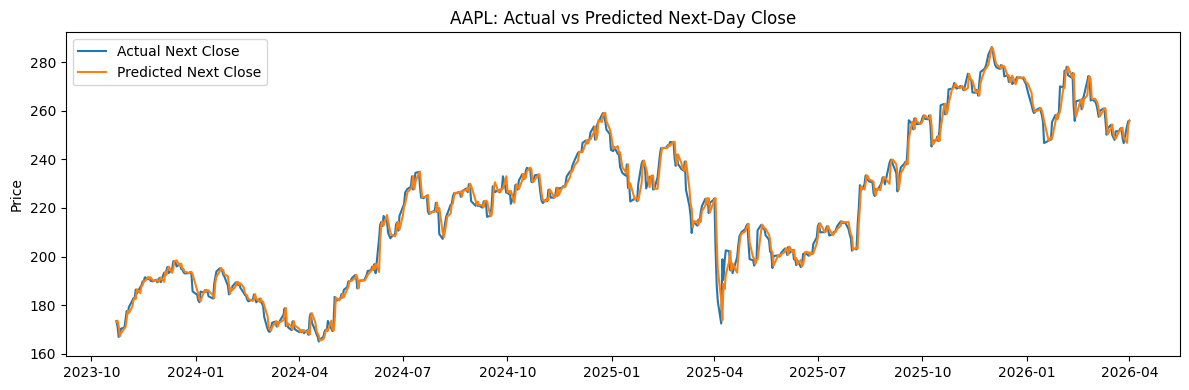

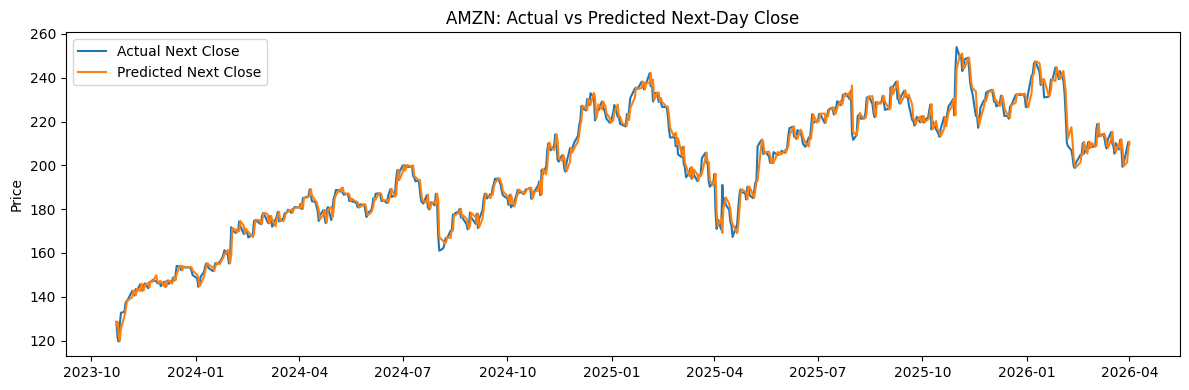

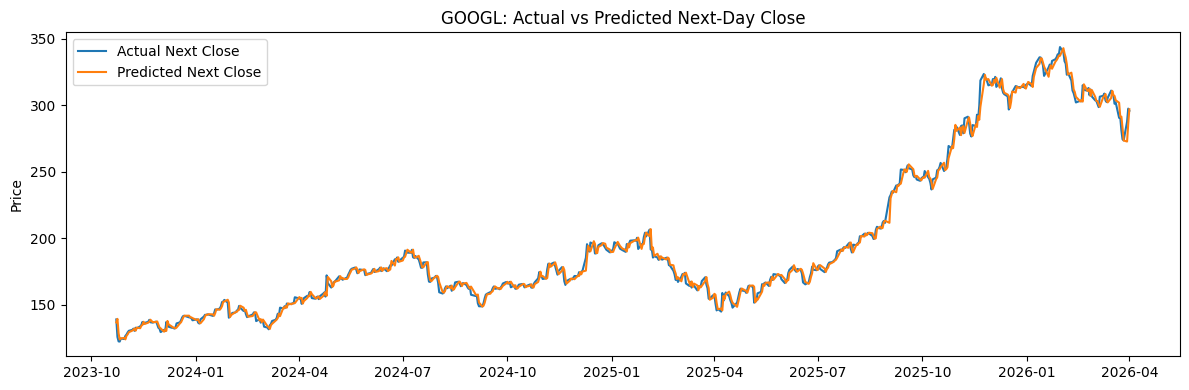

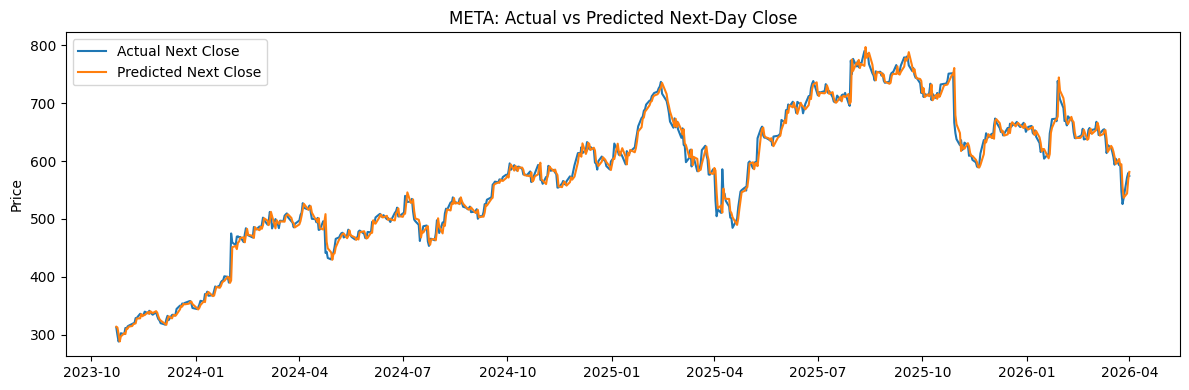

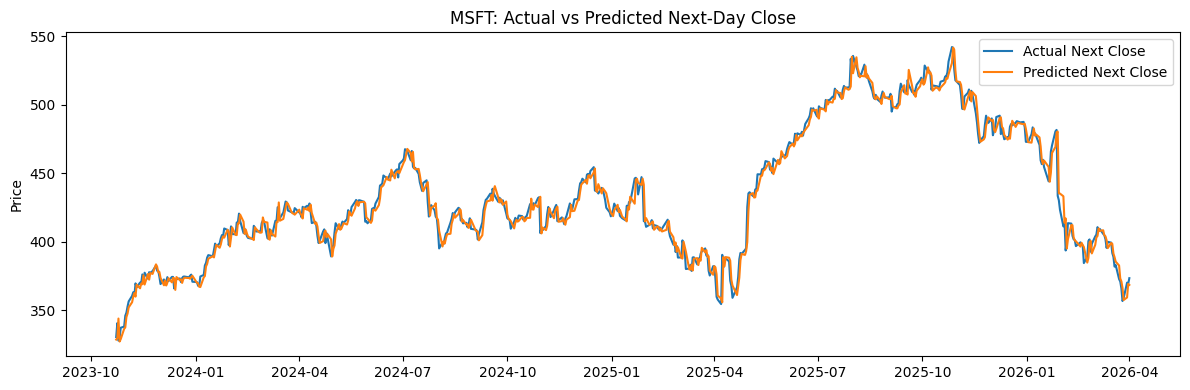

In [30]:
tickers = test_results["Ticker"].unique()

for ticker in tickers:
    temp = test_results[test_results["Ticker"] == ticker].sort_values("Date")

    plt.figure(figsize=(12, 4))
    plt.plot(temp["Date"], temp["Target_Next_Close"], label="Actual Next Close")
    plt.plot(temp["Date"], temp["Predicted_Next_Close"], label="Predicted Next Close")
    plt.title(f"{ticker}: Actual vs Predicted Next-Day Close")
    plt.xlabel("")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Main takeaway

This model satisfies the project requirement of using one generic forecasting model across all stocks.  
The evaluation by ticker shows whether the shared model performs similarly across companies or whether some stocks are harder to predict than others.

In general, exact next-day return prediction is difficult, so directional accuracy and relative price error are especially useful for interpretation.  
Further improvements could include boosting models such as XGBoost or LightGBM, more lag features, and market-wide indicators.